# **The House Always Loses?**
Bladen, Dov, & Lukas

# **Simulator**

**Assumptions Used for Deck/Hand Logic:**

**Deck**:
*   6-deck shoe (standard, 312 cards)
*   Real deck values {2-A} of 4 suits: spades, clubs, hearts, diamonds
*   Face cards (J, Q, K) all are worth 10 ⇒ 16 cards with value 10 per deck ($\mathbb{P} = \frac{4}{13}$)
*   Aces are worth 11, but drop to 1 if 11 forces bust (soft/hard)
*   Shoe reshuffles at 75% deck penetration (≤25% cards remain)
*   Running Count (RC) resets to 0 with each reshuffle
*   Cards are removed from the shoe until reshuffling

**Hand**:
*   hand_value always returns the best(optimal) total ≤21 by following soft/hard logic as needed
*   Soft Hand: contains an ace counted as 11
*   Hard Hand: either contains no ace, or all aces are counted as 1


**General Assumptions:**

*   Under infinite deck assumption: $\mathbb{P}(\text{any card value}) = \frac{1}{13}, \mathbb{P}(\text{10-value}) = \frac{4}{13}$
*   For player T, probabilities update based on Hi-Lo logic and groups after every card that's dealt $[\mathbb{P}(x|\text{shoe})=\frac{n_x}{N} \text{ where } n_x \text{ is cards of value x remaining}]$

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def build_deck(nd=6):
    single = [2,3,4,5,6,7,8,9,10,10,10,10,11]
    deck = single * 4 * nd
    random.shuffle(deck)
    return deck

In [ ]:
def hand_value(hand):
    total = sum(hand)
    aces = hand.count(11)
    while total > 21 and aces:
        total -= 10; aces -= 1
    return total

In [ ]:
def is_soft(hand):
    return 11 in hand and hand_value(hand) <= 21

In [ ]:
def hi_lo_tag(card):
    if card in [2,3,4,5,6]: return 1
    if card in [10,11]:      return -1
    return 0

In [ ]:
def hi_lo_cat(card):
    if card in [2,3,4,5,6]: return 'L'
    if card in [10,11]:      return 'H'
    return 'M'

In [ ]:
def true_count(rc, cards_left):
    return rc / max(cards_left/52, 0.5)

**Player Transition Matrix:**
So, this is actually sort of a misnomer because it didn't make sense for us to have a static transition matrix for the player.

But, the assumptions/rules implemented in the simulator are the following:

*   Very basic game (no doubling, splitting)
*   Blackjack "pays" 3:2 (standard)
*   Push on equal totals

In [ ]:
def card_probs(L, M, H, nd=6):
    D=nd; N=max(52*D-(L+M+H),1)
    pl=(max(20*D-L,0)/N)/5; pm=(max(12*D-M,0)/N)/3
    pt=(max(20*D-H,0)/N)*0.8; pa=(max(20*D-H,0)/N)*0.2
    return {2:pl,3:pl,4:pl,5:pl,6:pl,7:pm,8:pm,9:pm,10:pt,11:pa}

**Dealer Markov Chain:**

Dealer plays by the book:
*   Stands on all 17s (including soft 17)
*   Dealer hits on any hand_total < 17
*   Dealer down card is revealed after player acts

First, we raised T to the 17th power because we needed the full probability distribution over the dealer's absorbing states {17,18,19,20,21,bust}, from any starting dealer upcard because n=17 steps guarantees every dealer path is covered.


In [ ]:
def dealer_outcomes(upcard, probs):
    """P(dealer final total) from T^17 given current shoe probs."""
    hard = list(range(4,22)) + ['bust']
    soft = [f's{i}' for i in range(12,22)]
    states = hard + soft
    idx = {s:i for i,s in enumerate(states)}
    n = len(states)
    T = np.zeros((n,n))

    def absorb(s):
        if s == 'bust': return True
        if isinstance(s, int): return s >= 17
        return int(s[1:]) >= 17

    for s in states:
        if absorb(s):
            T[idx[s],idx[s]] = 1.0
            continue
        for card, prob in probs.items():
            if prob == 0: continue
            if isinstance(s, str):       # soft state
                cur = int(s[1:])
                if card == 11:           # another ace -> counts as 1
                    nt = cur + 1; ns = nt if nt <= 21 else 'bust'
                else:
                    nt = cur + card
                    if nt > 21:          # drop ace
                        nt2 = cur - 10 + card
                        ns = 'bust' if nt2 > 21 else nt2
                    else:
                        ns = f's{nt}'
            else:                        # hard state
                if card == 11:
                    ns = f's{s+11}' if s+11 <= 21 else (s+1 if s+1 <= 21 else 'bust')
                else:
                    nt = s + card
                    ns = 'bust' if nt > 21 else nt
            if ns not in idx: ns = 'bust'
            T[idx[s], idx[ns]] += prob

    v = np.zeros(n)
    if upcard in idx: v[idx[upcard]] = 1.0
    dist = v @ np.linalg.matrix_power(T, 17)

    out = {}
    for s, i in idx.items():
        if not absorb(s): continue
        k = 'bust' if s=='bust' else (int(s[1:]) if isinstance(s,str) else s)
        out[k] = out.get(k, 0) + dist[i]
    return out


**Expected Value of Standing vs. Hitting:**

In [ ]:
def e_stand(ptotal, upcard, probs):
    """E[stand|s] = P(win) - P(lose) using dealer chain."""
    out = dealer_outcomes(upcard, probs)
    ev = 0
    for d, p in out.items():
        if d == 'bust' or (isinstance(d,int) and d < ptotal): ev += p
        elif isinstance(d,int) and d > ptotal:                ev -= p
    return ev

In [ ]:
def e_hit(ptotal, soft, upcard, probs, memo):
    """E[hit|s] = sum_{s'} P(s'|s) * V(s') recursively."""
    key = (ptotal, soft, upcard)
    if key in memo: return memo[key]
    ev = 0
    for card, prob in probs.items():
        if prob == 0: continue
        if soft:
            if card == 11:  nt = ptotal+1;  ns = False
            else:
                nt = ptotal+card; ns = nt <= 21
                if nt > 21: nt -= 10; ns = False
        else:
            if card == 11:
                if ptotal+11 <= 21: nt = ptotal+11; ns = True
                else:               nt = ptotal+1;  ns = False
            else: nt = ptotal+card; ns = False

        if nt > 21:   ev += prob * (-1)
        elif nt == 21: ev += prob * e_stand(21, upcard, probs)
        else:
            es = e_stand(nt, upcard, probs)
            eh = e_hit(nt, ns, upcard, probs, memo)
            ev += prob * max(es, eh)
    memo[key] = ev
    return ev


**Optimal Strategy as Defined by Lookup Table:**

In [ ]:
def build_optimal_table(L, M, H, nd=6):
    """
    Compute π*(s) = argmax{E[stand], E[hit]} for all states
    given current shoe composition L, M, H.
    Returns dict: (ptotal, soft, upcard) -> 'hit'/'stand'
    """
    probs = card_probs(L, M, H, nd)
    memo = {}
    table = {}
    for upcard in [2,3,4,5,6,7,8,9,10,11]:
        for ptotal in range(4, 21):
            for soft in [False, True]:
                if soft and ptotal < 12: continue
                # Totals <= 11 can never bust on a hit — always hit
                if ptotal <= 11 and not soft:
                    table[(ptotal, soft, upcard)] = 'hit'
                    continue
                es = e_stand(ptotal, upcard, probs)
                eh = e_hit(ptotal, soft, upcard, probs, memo)
                table[(ptotal, soft, upcard)] = 'stand' if es >= eh else 'hit'
    return table

In [ ]:
# Precompute tables at key TC levels using representative L,M,H values
# TC ≈ 0:  fresh shoe
# TC ≈ +3: shoe significantly rich in high cards
# TC ≈ -3: shoe rich in low cards
print("Precomputing optimal strategy tables (3 shoe states)...")
TABLE_FRESH = build_optimal_table(0,   0,  0,  6)   # TC ≈ 0
TABLE_HOT   = build_optimal_table(72, 35, 45, 6)    # TC ≈ +3 (low cards depleted)
TABLE_COLD  = build_optimal_table(45, 35, 72, 6)    # TC ≈ -3 (high cards depleted)
print("Tables built.")

Precomputing optimal strategy tables (3 shoe states)...
Tables built.


In [ ]:
def lookup_optimal(ptotal, upcard, soft, tc):
    """Select table based on TC bin, return π*(s)."""
    if tc >= 2:   table = TABLE_HOT
    elif tc <= -2: table = TABLE_COLD
    else:          table = TABLE_FRESH
    key = (ptotal, soft, upcard)
    return table.get(key, 'hit')   # default hit if not found (low totals)

**The Four Strategies We're Comparing:**

In [ ]:
def random_strategy(ptotal, upcard, soft, tc, L, M, H, nd):
    return random.choice(['hit','stand'])

In [ ]:
def basic_strategy(ptotal, upcard, soft, tc, L, M, H, nd):
    d = upcard
    if soft:
        if ptotal >= 19: return 'stand'
        if ptotal == 18: return 'hit' if d in [9,10,11] else 'stand'
        return 'hit'
    else:
        if ptotal >= 17: return 'stand'
        if ptotal >= 13: return 'stand' if d in [2,3,4,5,6] else 'hit'
        if ptotal == 12: return 'stand' if d in [4,5,6] else 'hit'
        return 'hit'

In [ ]:
def optimal_ev_strategy(ptotal, upcard, soft, tc, L, M, H, nd):
    """π* from precomputed EV table — flat bet."""
    return lookup_optimal(ptotal, upcard, soft, tc)

In [ ]:
def hi_lo_optimal_strategy(ptotal, upcard, soft, tc, L, M, H, nd):
    """π* from precomputed EV table + variable bet sizing."""
    return lookup_optimal(ptotal, upcard, soft, tc)

**Hi-Lo Bets Increment in Units of 12:**

In [ ]:
def hi_lo_bet(tc):
    if tc <= 1: return 1
    if tc <= 2: return 2
    if tc <= 3: return 4
    if tc <= 4: return 8
    return 20

In [ ]:
def resolve(pt, dt, pbj=False):
    if pt > 21:               return -1
    if pbj and dt != 21:      return 1.5
    if dt > 21:               return 1
    if pt > dt:               return 1
    if pt < dt:               return -1
    return 0

**Game Simulator:**

In [ ]:
def dealer_play(hand, deck):
    while hand_value(hand) < 17:
        hand.append(deck.pop())
    return hand

In [ ]:
def play_hand(strategy_fn, deck, rc, L, M, H, nd=6):
    def count(card, rc, L, M, H):
        rc += hi_lo_tag(card)
        c = hi_lo_cat(card)
        if c=='L': L+=1
        elif c=='M': M+=1
        else: H+=1
        return rc, L, M, H

    ph = [deck.pop(), deck.pop()]
    dh = [deck.pop(), deck.pop()]

    for c in ph + [dh[0]]:
        rc, L, M, H = count(c, rc, L, M, H)

    tc  = true_count(rc, len(deck))
    bet = hi_lo_bet(tc) if strategy_fn == hi_lo_optimal_strategy else 1

    pbj = hand_value(ph) == 21
    dbj = hand_value(dh) == 21

    if pbj or dbj:
        rc, L, M, H = count(dh[1], rc, L, M, H)
        return resolve(hand_value(ph), hand_value(dh), pbj)*bet, bet, rc, L, M, H

    rc, L, M, H = count(dh[1], rc, L, M, H)

    while True:
        pt = hand_value(ph)
        if pt >= 21: break
        tc = true_count(rc, len(deck))
        action = strategy_fn(pt, dh[0], is_soft(ph), tc, L, M, H, nd)
        if action == 'stand': break
        card = deck.pop()
        rc, L, M, H = count(card, rc, L, M, H)
        ph.append(card)

    pt = hand_value(ph)
    if pt > 21:
        return -1*bet, bet, rc, L, M, H

    dh = dealer_play(dh, deck)
    for c in dh[2:]:
        rc, L, M, H = count(c, rc, L, M, H)

    return resolve(pt, hand_value(dh))*bet, bet, rc, L, M, H

In [ ]:
def simulate(strategy_fn, num_hands=50_000, nd=6, start=1000):
    deck = build_deck(nd)
    bankroll = start
    hist = [bankroll]
    rc = L = M = H = 0
    wagered = 0
    cutoff = int(nd * 52 * 0.25)

    for _ in range(num_hands):
        if len(deck) < cutoff:
            deck = build_deck(nd)
            rc = L = M = H = 0
        payout, bet, rc, L, M, H = play_hand(strategy_fn, deck, rc, L, M, H, nd)
        bankroll += payout
        wagered  += bet
        hist.append(bankroll)

    return hist, wagered

In [ ]:
NUM_HANDS = 50_000
START     = 1_000
ND        = 6

print(f"\nSimulating {NUM_HANDS:,} hands each...")

random.seed(42)
r_hist, r_wag = simulate(random_strategy,       NUM_HANDS, ND, START)
print("  Random done.")

random.seed(42)
b_hist, b_wag = simulate(basic_strategy,        NUM_HANDS, ND, START)
print("  Basic strategy done.")

random.seed(42)
e_hist, e_wag = simulate(optimal_ev_strategy,   NUM_HANDS, ND, START)
print("  Optimal EV done.")

random.seed(42)
h_hist, h_wag = simulate(hi_lo_optimal_strategy,NUM_HANDS, ND, START)
print("  Hi-Lo Optimal done.")

def he(hist, start, wag):
    return -(hist[-1]-start)/wag*100


Simulating 50,000 hands each...
  Random done.
  Basic strategy done.
  Optimal EV done.
  Hi-Lo Optimal done.


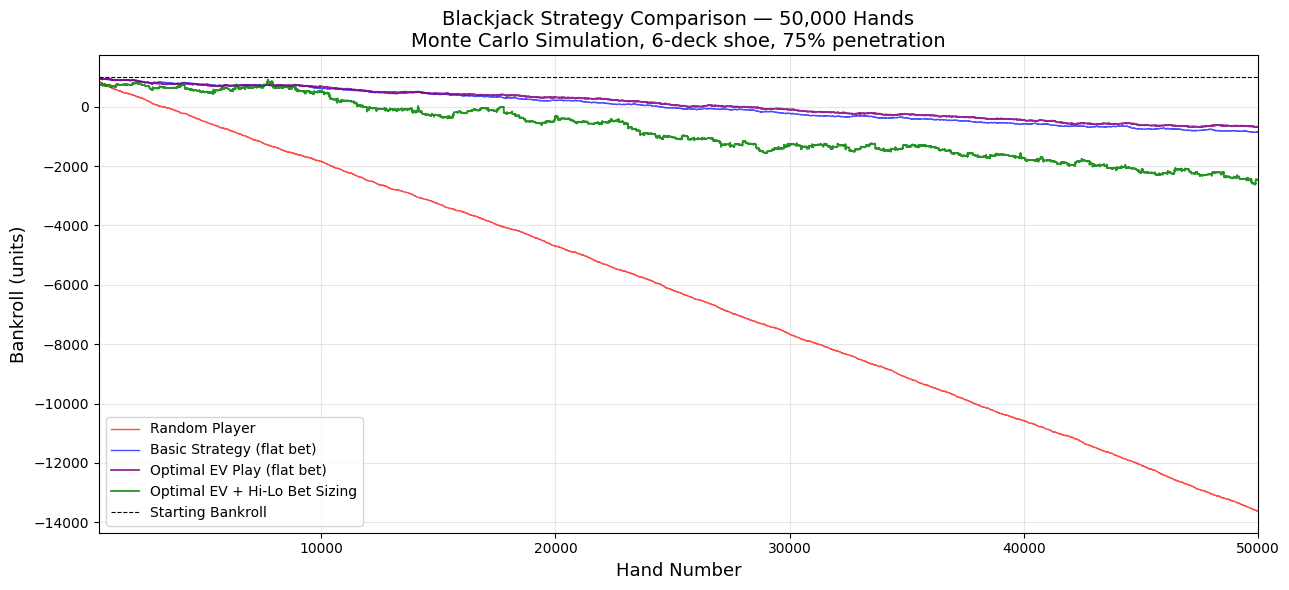

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
hands = range(NUM_HANDS + 1)

ax.plot(hands, r_hist, label='Random Player',                  color='red',    alpha=0.7,  lw=1)
ax.plot(hands, b_hist,  label='Basic Strategy (flat bet)',      color='blue',   alpha=0.7,  lw=1)
ax.plot(hands, e_hist,     label='Optimal EV Play (flat bet)',     color='purple', alpha=0.85, lw=1.3)
ax.plot(hands, h_hist,   label='Optimal EV + Hi-Lo Bet Sizing',  color='green',  alpha=0.85, lw=1.3)
ax.axhline(START, color='black', ls='--', lw=0.8, label='Starting Bankroll')

ax.set_xlim(500, NUM_HANDS)
ax.set_xlabel('Hand Number', fontsize=13)
ax.set_ylabel('Bankroll (units)', fontsize=13)
ax.set_title(f'Blackjack Strategy Comparison — {NUM_HANDS:,} Hands\n'
             f'Monte Carlo Simulation, {ND}-deck shoe, 75% penetration', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('blackjack_bankroll.png', dpi=300, bbox_inches='tight')
plt.show()

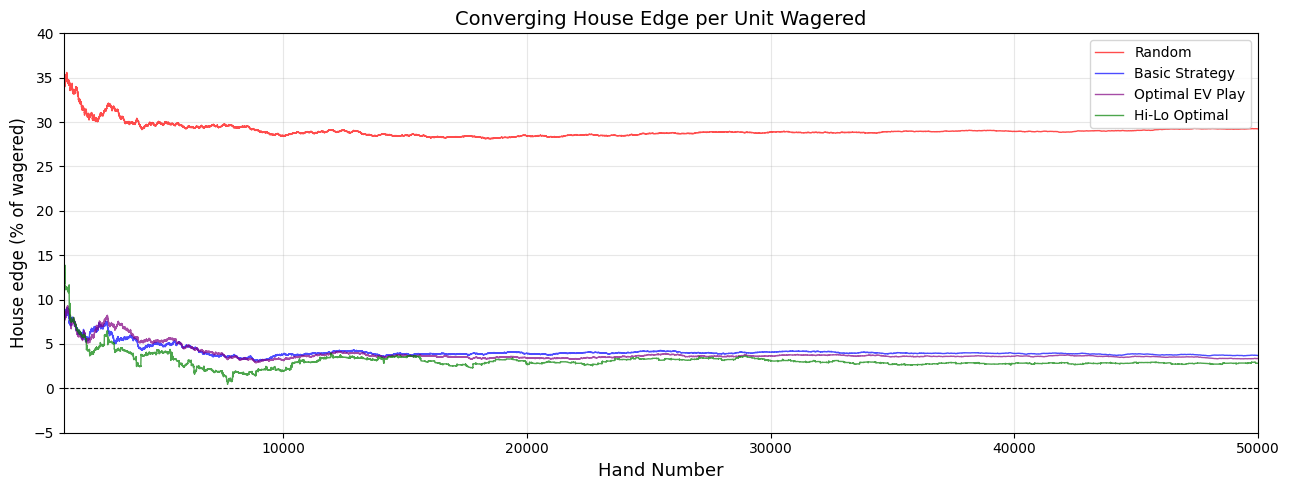

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
hand_nums = np.arange(1, NUM_HANDS + 1)

for hist, wag, col, lbl in [
    (r_hist, r_wag, 'red',    'Random'),
    (b_hist,  b_wag, 'blue',   'Basic Strategy'),
    (e_hist,     e_wag, 'purple', 'Optimal EV Play'),
    (h_hist,   h_wag, 'green',  'Hi-Lo Optimal'),
]:
    running_net = np.array(hist[1:]) - START
    running_wag = np.linspace(wag/NUM_HANDS, wag, NUM_HANDS)
    running_he  = -running_net / running_wag * 100
    ax.plot(hand_nums, running_he, label=lbl, color=col, alpha=0.7, lw=1)

ax.axhline(0, color='black', ls='--', lw=0.8)
ax.set_xlim(1000, NUM_HANDS)
ax.set_ylim(-5, 40)
ax.set_xlabel('Hand Number', fontsize=13)
ax.set_ylabel('House edge (% of wagered)', fontsize=12)
ax.set_title('Converging House Edge per Unit Wagered', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('blackjack_house_edge.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
print(f"\n{'='*70}")
print(f"{'Monte Carlo Results':^70}")
print(f"{f'{NUM_HANDS:,} hands | {ND}-deck shoe | 75% penetration':^70}")
print(f"{'='*70}")
print(f"{'Strategy':<32} {'Net':>8} {'E[ret]/hand':>12} {'House edge':>11} {'Wagered':>8}")
print(f"{'-'*70}")

for lbl, hist, wag in [
    ('Random Player',               r_hist, r_wag),
    ('Basic Strategy (flat)',       b_hist, b_wag),
    ('Optimal EV Play (flat)',      e_hist, e_wag),
    ('Optimal EV + Hi-Lo Bet',      h_hist, h_wag),
]:
    net = hist[-1]-START
    er  = net/NUM_HANDS
    hedge = he(hist, START, wag)
    print(f"{lbl:<32} {net:>+8,.0f} {er:>+12.4f} {hedge:>+10.2f}% {wag:>8,.0f}")

print(f"{'='*70}")



                         Monte Carlo Results                          
             50,000 hands | 6-deck shoe | 75% penetration             
Strategy                              Net  E[ret]/hand  House edge  Wagered
----------------------------------------------------------------------
Random Player                     -14,621      -0.2924     +29.24%   50,000
Basic Strategy (flat)              -1,852      -0.0370      +3.70%   50,000
Optimal EV Play (flat)             -1,680      -0.0336      +3.36%   50,000
Optimal EV + Hi-Lo Bet             -3,458      -0.0692      +2.83%  122,193


In [ ]:
print("States where Optimal EV (fresh shoe) diverges from Basic Strategy:")
print(f"{'State (total, soft, upcard)':<35} {'Basic':>8} {'Optimal EV':>12}")
print("-"*55)
diverged = 0
for upcard in [2,3,4,5,6,7,8,9,10,11]:
    for ptotal in range(4,21):
        for soft in [False,True]:
            if soft and ptotal < 12: continue
            key = (ptotal, soft, upcard)
            bs  = basic_strategy(ptotal, upcard, soft, 0, 0, 0, 0, 6)
            opt = TABLE_FRESH.get(key, '?')
            if bs != opt:
                label = f"({'soft' if soft else 'hard'} {ptotal}, dealer {upcard})"
                print(f"  {label:<33} {bs:>8} {opt:>12}")
                diverged += 1
if diverged == 0:
    print("  None — π* agrees with basic strategy at fresh shoe (TC≈0)")
print(f"\nTotal divergences at fresh shoe: {diverged}")


States where Optimal EV (fresh shoe) diverges from Basic Strategy:
State (total, soft, upcard)            Basic   Optimal EV
-------------------------------------------------------
  (hard 12, dealer 2)                    hit        stand
  (soft 12, dealer 2)                    hit        stand
  (soft 13, dealer 2)                    hit        stand
  (soft 14, dealer 2)                    hit        stand
  (soft 15, dealer 2)                    hit        stand
  (soft 16, dealer 2)                    hit        stand
  (soft 17, dealer 2)                    hit        stand
  (hard 12, dealer 3)                    hit        stand
  (soft 12, dealer 3)                    hit        stand
  (soft 13, dealer 3)                    hit        stand
  (soft 14, dealer 3)                    hit        stand
  (soft 15, dealer 3)                    hit        stand
  (soft 16, dealer 3)                    hit        stand
  (soft 17, dealer 3)                    hit        stand
  (hard